<a href="https://colab.research.google.com/github/palvi83ingle-stack/ecommerce-sql-data-analysis/blob/main/Copy_of_Ecommerce_Customer_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 1. LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Data Understanding***

In [ ]:
#shape#
print("CUSTOMERS_CLEANED:", customers.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

CUSTOMERS_CLEANED: (1000, 10)
Products: (2000, 12)
Sales: (250000, 21)


In [ ]:
#Statistical summary#
sales.describe(include='all')


,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,...,Review_Text,City,State,Customer_Age,Customer_Age_Group,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Order_WeekOfYear
count,250000,250000,250000,250000,250000,250000,250000.000000,250000.000000,250000.000000,250000.000000,...,120030,250000,250000,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
unique,250000,39914,2000,NaN,1440,NaN,NaN,NaN,NaN,NaN,...,9,39,10,NaN,6,NaN,NaN,NaN,NaN,NaN
top,ORD0000249984,CUST00005290,PROD000004,NaN,11:27:00,NaN,NaN,NaN,NaN,NaN,...,Amazing quality!,Madurai,UP,NaN,26-35,NaN,NaN,NaN,NaN,NaN
freq,1,19,267,NaN,219,NaN,NaN,NaN,NaN,NaN,...,20176,6946,32631,NaN,87847,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2025-06-15 09:37:10.156799744,NaN,2025-06-19 21:38:16.512000,1.249580,19202.477645,23967.862192,4.911971,...,NaN,NaN,NaN,35.309416,NaN,2024.956796,6.499888,15.697780,2.999596,26.384720
min,NaN,NaN,NaN,2024-06-01 00:00:00,NaN,2024-06-03 00:00:00,1.000000,26.130000,26.130000,0.000000,...,NaN,NaN,NaN,18.000000,NaN,2024.000000,1.000000,1.000000,0.000000,1.000000
25%,NaN,NaN,NaN,2024-12-08 00:00:00,NaN,2024-12-13 00:00:00,1.000000,1551.550000,1825.890000,0.000000,...,NaN,NaN,NaN,26.000000,NaN,2024.000000,4.000000,8.000000,1.000000,14.000000
50%,NaN,NaN,NaN,2025-06-15 00:00:00,NaN,2025-06-19 00:00:00,1.000000,7208.930000,8411.160000,0.000000,...,NaN,NaN,NaN,33.000000,NaN,2025.000000,6.000000,16.000000,3.000000,26.000000
75%,NaN,NaN,NaN,2025-12-22 00:00:00,NaN,2025-12-27 00:00:00,1.000000,24433.270000,28612.810000,0.000000,...,NaN,NaN,NaN,43.000000,NaN,2025.000000,9.000000,23.000000,5.000000,39.000000
max,NaN,NaN,NaN,2026-06-30 00:00:00,NaN,2026-07-07 00:00:00,3.000000,136973.330000,410919.990000,90.000000,...,NaN,NaN,NaN,75.000000,NaN,2026.000000,12.000000,31.000000,6.000000,52.000000


***Data-quality analysis***

### Missing Values in `customers` DataFrame

In [ ]:
print("CUSTOMERS_CLEANED Missing Values:")
display(customers.isnull().sum())

CUSTOMERS_CLEANED Missing Values:


,0
Customer_ID,0
Gender,0
Age,0
Age_Group,0
City,0
State,0
Registration_Date,0
Customer_Tier,0
Total_Orders,0
Total_Spent,0


### Missing Values in `products` DataFrame

In [ ]:
print("Products Missing Values:")
display(products.isnull().sum())

Products Missing Values:


,0
Product_ID,0
Product_Name,0
Category,0
Brand,0
Original_Price,0
Discount_Percent,0
Discount_Amount,0
Selling_Price,0
Stock_Quantity,0
Weight_kg,0


### Missing Values in `sales` DataFrame

In [ ]:
print("Sales Missing Values:")
display(sales.isnull().sum())

Sales Missing Values:


,0
Order_ID,0
Customer_ID,0
Product_ID,0
Order_Date,0
Order_Time,0
Delivery_Date,0
Quantity,0
Unit_Price,0
Order_Value,0
Shipping_Cost,0


### Duplicate Values in DataFrames

In [ ]:
print("CUSTOMERS_CLEANED Duplicate Values:", customers.duplicated().sum())

CUSTOMERS_CLEANED Duplicate Values: 0


In [ ]:
print("Products Duplicate Values:", products.duplicated().sum())

Products Duplicate Values: 0


In [ ]:
print("Sales Duplicate Values:", sales.duplicated().sum())

Sales Duplicate Values: 0


### Unique Values in DataFrames

In [ ]:
dataframes_list = {'CUSTOMERS_CLEANED': customers, 'Products': products, 'Sales': sales}

for df_name, df in dataframes_list.items():
    print(f"\n--- Unique Values for {df_name} ---")
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"  Column '{col}': {unique_count} unique values")
        if unique_count <= 20:
            print(f"    Unique values: {df[col].unique()}")


--- Unique Values for CUSTOMERS_CLEANED ---
  Column 'Customer_ID': 1000 unique values
  Column 'Gender': 2 unique values
    Unique values: ['male' 'female']
  Column 'Age': 58 unique values
  Column 'Age_Group': 6 unique values
    Unique values: ['46-55' '65+' '26-35' '36-45' '18-25' '56-65']
  Column 'City': 39 unique values
  Column 'State': 10 unique values
    Unique values: ['Punjab' 'West Bengal' 'Haryana' 'UP' 'Rajasthan' 'Karnataka'
 'Maharashtra' 'Delhi' 'Tamil Nadu' 'Gujarat']
  Column 'Registration_Date': 339 unique values
  Column 'Customer_Tier': 3 unique values
    Unique values: ['Gold' 'Platinum' 'Silver']
  Column 'Total_Orders': 15 unique values
    Unique values: [ 5  8  0  4  6  7  3  9  2 10  1 12 14 13 11]
  Column 'Total_Spent': 994 unique values

--- Unique Values for Products ---
  Column 'Product_ID': 2000 unique values
  Column 'Product_Name': 350 unique values
  Column 'Category': 7 unique values
    Unique values: ['Electronics' 'Fashion' 'Home' 'Beauty

### Date Conversion and Time-Based Feature Extraction for `sales` DataFrame (Already Completed)

In [ ]:
print("Sales DataFrame Info:")
sales.info()

Sales DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order_ID            250000 non-null  object        
 1   Customer_ID         250000 non-null  object        
 2   Product_ID          250000 non-null  object        
 3   Order_Date          250000 non-null  datetime64[ns]
 4   Order_Time          250000 non-null  object        
 5   Delivery_Date       250000 non-null  datetime64[ns]
 6   Quantity            250000 non-null  int64         
 7   Unit_Price          250000 non-null  float64       
 8   Order_Value         250000 non-null  float64       
 9   Shipping_Cost       250000 non-null  float64       
 10  Coupon_Code         50185 non-null   object        
 11  Coupon_Discount     250000 non-null  float64       
 12  Total_Amount        250000 non-null  float64       
 13  Payment

### Existing Time-Based Features in `sales` DataFrame

In [ ]:
display(sales[['Order_Date', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_DayOfWeek', 'Order_WeekOfYear']].head())

,Order_Date,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Order_WeekOfYear
0,2026-06-07,2026,6,7,6,23
1,2025-02-04,2025,2,4,1,6
2,2026-03-12,2026,3,12,3,11
3,2025-01-27,2025,1,27,0,5
4,2024-06-30,2024,6,30,6,26


Create the master analytical dataset

In [ ]:
# Clean the 'ï»¿Customer_ID' column name in customers DataFrame
customers.rename(columns={'ï»¿Customer_ID': 'Customer_ID'}, inplace=True)

# Merge sales and customers DataFrames on 'Customer_ID'
master_df = pd.merge(sales, customers, on='Customer_ID', how='inner')

print("Shape of the master analytical dataset:", master_df.shape)
display(master_df.head())

Shape of the master analytical dataset: (6174, 35)


,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,...,Order_WeekOfYear,Gender,Age,Age_Group,City_y,State_y,Registration_Date,Customer_Tier,Total_Orders,Total_Spent
0,ORD0000000003,CUST00000421,PROD000318,2026-03-12,14:59:00,2026-03-19,1,3536.50,3536.50,0.0,...,11,female,41,36-45,Patiala,Punjab,2023-06-14,Platinum,7,201868.75
1,ORD0000000014,CUST00000924,PROD001923,2024-12-27,18:53:00,2024-12-29,1,1266.14,1266.14,0.0,...,52,male,74,65+,Sohna,Haryana,2023-07-14,Silver,7,10570.82
2,ORD0000000054,CUST00000602,PROD000534,2026-01-25,16:35:00,2026-01-30,1,6775.60,6775.60,0.0,...,4,male,26,26-35,Jaipur,Rajasthan,2023-06-30,Platinum,4,100292.27
3,ORD0000000110,CUST00000210,PROD000422,2025-06-22,03:20:00,2025-06-25,1,45035.98,45035.98,0.0,...,25,female,29,26-35,Dwarka,Delhi,2023-08-29,Platinum,4,163263.10
4,ORD0000000119,CUST00000454,PROD001890,2026-02-07,12:47:00,2026-02-12,1,2117.61,2117.61,0.0,...,6,male,46,46-55,Ahmedabad,Gujarat,2023-06-12,Gold,7,41312.79


In [ ]:
master_df = pd.merge(master_df, products, on='Product_ID', how='inner')

print("Shape of the master analytical dataset after adding products:", master_df.shape)
display(master_df.head())

Shape of the master analytical dataset after adding products: (6174, 46)


,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,...,Category,Brand,Original_Price,Discount_Percent,Discount_Amount,Selling_Price,Stock_Quantity,Weight_kg,Avg_Rating,Total_Reviews
0,ORD0000000003,CUST00000421,PROD000318,2026-03-12,14:59:00,2026-03-19,1,3536.50,3536.50,0.0,...,Electronics,boAt,7073.01,50,3536.51,3536.50,749,3.61,4.32,109
1,ORD0000000014,CUST00000924,PROD001923,2024-12-27,18:53:00,2024-12-29,1,1266.14,1266.14,0.0,...,Grocery,Lays,2532.28,50,1266.14,1266.14,463,4.63,4.57,54
2,ORD0000000054,CUST00000602,PROD000534,2026-01-25,16:35:00,2026-01-30,1,6775.60,6775.60,0.0,...,Fashion,Titan,7528.45,10,752.85,6775.60,339,0.55,4.53,78
3,ORD0000000110,CUST00000210,PROD000422,2025-06-22,03:20:00,2025-06-25,1,45035.98,45035.98,0.0,...,Electronics,HP,86607.65,48,41571.67,45035.98,940,1.55,4.41,113
4,ORD0000000119,CUST00000454,PROD001890,2026-02-07,12:47:00,2026-02-12,1,2117.61,2117.61,0.0,...,Grocery,Haldiram,2750.14,23,632.53,2117.61,192,0.85,4.38,63


***Create business metrics***

In [ ]:
# KPI 1: Total Revenue
total_revenue = master_df['Total_Amount'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $144,196,911.24


In [ ]:
# KPI 2: Total Orders
total_orders = master_df['Order_ID'].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 6174


In [ ]:
# KPI 3: Total Customers
total_customers = master_df['Customer_ID'].nunique()
print(f"Total Customers: {total_customers}")

Total Customers: 999


In [ ]:
# KPI 4: Total Products Sold
total_products_sold = master_df['Quantity'].sum()
print(f"Total Products Sold: {total_products_sold}")

Total Products Sold: 7693


In [ ]:
# KPI 5: Average Order Value
average_order_value = total_revenue / total_orders
print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $23,355.51


In [ ]:
# Monthly Sales Analysis
monthly_sales = master_df.groupby('Order_Month')['Total_Amount'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(by='Order_Month')
print("Monthly Sales:")
display(monthly_sales)

Monthly Sales:


,Order_Month,Total_Amount
0,1,11137695.13
1,2,10190116.52
2,3,9918680.34
3,4,11674181.97
4,5,11458564.36
5,6,18326758.76
6,7,12608073.39
7,8,11670993.15
8,9,11323036.98
9,10,11417268.65


/tmp/ipykernel_4735/1655180530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order_Month', y='Total_Amount', data=monthly_sales, palette='viridis')


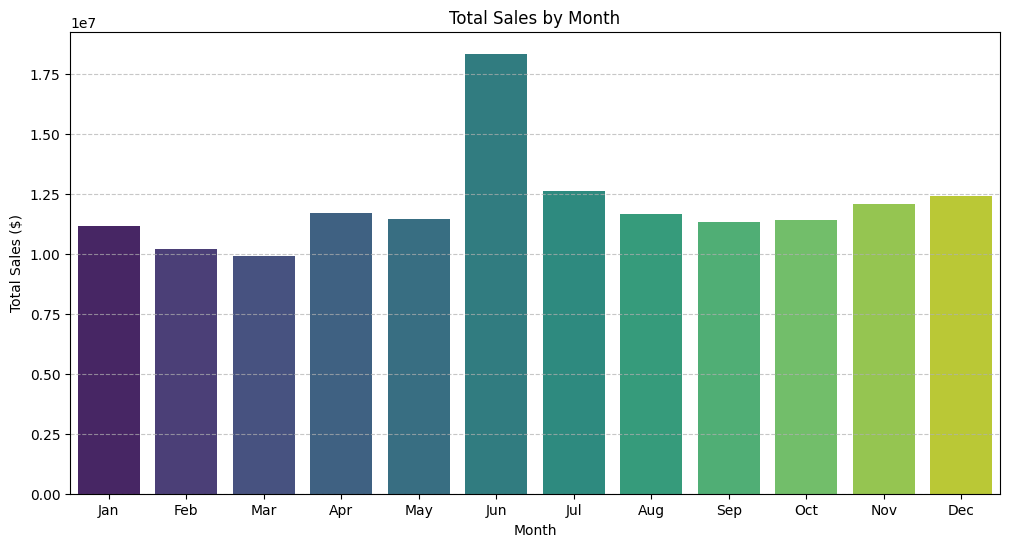

In [ ]:
# Visualize Monthly Sales
plt.figure(figsize=(12, 6))
sns.barplot(x='Order_Month', y='Total_Amount', data=monthly_sales, palette='viridis')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Monthly Sales Analysis Interpretation

Based on the monthly sales data and the generated bar chart:

*   **Overall Trend:** The plot shows a varied pattern in monthly sales rather than a consistent growth or decline throughout the year. Sales fluctuate significantly across different months.
*   **Seasonal Patterns:** There's a clear **peak in June**, which stands out as an unusually high month for revenue. Sales in June are significantly higher than any other month, almost reaching $18 million. There also appears to be a slight increase towards the end of the year (November and December).
*   **Lower Sales:** March seems to be an unusually low month for sales, with revenue just under $10 million. February also shows relatively lower sales compared to other months.
*   **Other Observations:** Sales are relatively stable, with minor fluctuations, for most other months, ranging between approximately $10 million and $12.5 million.

## Yearly Sales Analysis

In [ ]:
yearly_sales = master_df.groupby('Order_Year')['Total_Amount'].sum().reset_index()
yearly_sales = yearly_sales.sort_values(by='Order_Year')
print("Yearly Sales:")
display(yearly_sales)

Yearly Sales:


,Order_Year,Total_Amount
0,2024,41546083.40
1,2025,69947719.88
2,2026,32703107.96


/tmp/ipykernel_4735/2423823513.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order_Year', y='Total_Amount', data=yearly_sales, palette='viridis')


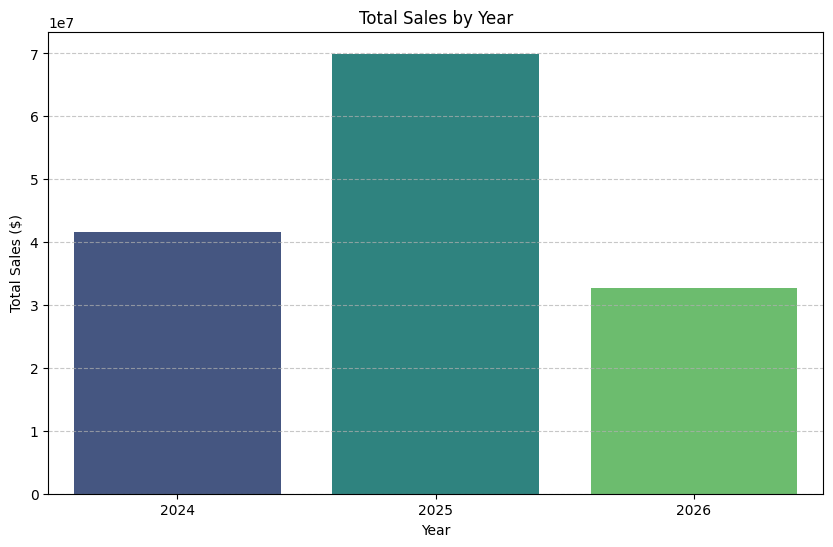

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Order_Year', y='Total_Amount', data=yearly_sales, palette='viridis')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Yearly Sales Analysis Interpretation

Based on the yearly sales data and the generated bar chart:

*   **2025 Dominance:** The year 2025 shows significantly higher sales compared to both 2024 and 2026, with a total revenue of approximately $69.95 million. This indicates a very strong performance in 2025, potentially due to successful campaigns, market conditions, or increased customer activity during that year.
*   **Growth from 2024 to 2025:** There was a substantial increase in sales from 2024 (approximately $41.55 million) to 2025. This suggests a period of growth for the e-commerce platform.
*   **Decline in 2026:** Sales in 2026 (approximately $32.70 million) show a noticeable decline compared to 2025, and are even lower than the sales in 2024. This could indicate a downward trend, a shorter sales period for 2026 in the dataset, or other factors affecting sales performance in that year. It's important to note that the data for 2026 might not cover a full year, which could explain the lower total.

## Category Performance Analysis

In [ ]:
category_sales = master_df.groupby('Category')['Total_Amount'].sum().reset_index()
category_sales = category_sales.sort_values(by='Total_Amount', ascending=False)
print("Category Sales Performance:")
display(category_sales)

Category Sales Performance:


,Category,Total_Amount
2,Electronics,1.038776e+08
5,Home,1.795478e+07
6,Sports,1.184925e+07
3,Fashion,8.016520e+06
4,Grocery,1.132182e+06
0,Beauty,9.332999e+05
1,Books,4.332698e+05


/tmp/ipykernel_4735/523432556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Amount', y='Category', data=category_sales, palette='viridis')


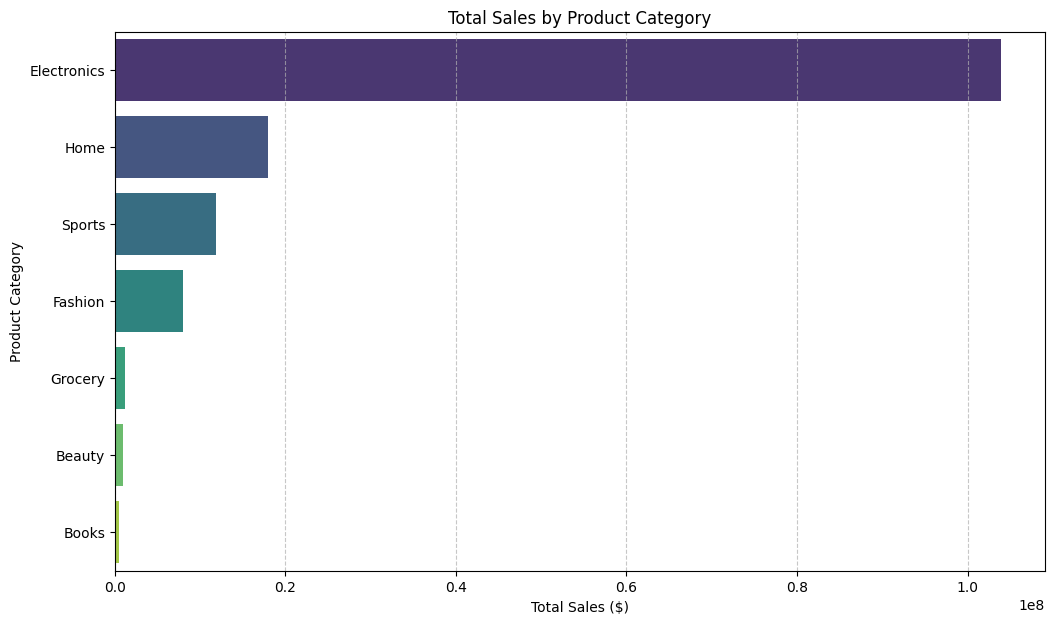

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Total_Amount', y='Category', data=category_sales, palette='viridis')
plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Category Performance Interpretation

Based on the category sales data and the generated bar chart:

*   **Electronics Dominance:** The 'Electronics' category is by far the highest-performing category, generating over $103 million in total sales. This indicates that electronics products are the primary revenue driver for the e-commerce platform.
*   **Mid-Tier Categories:** 'Home' and 'Sports' are the next significant categories, with sales of approximately $17.9 million and $11.8 million, respectively. These categories contribute moderately to the overall revenue but are far behind electronics.
*   **Fashion Performance:** 'Fashion' also holds a notable position with around $8 million in sales, making it a strong contributor but still a tier below Home and Sports.
*   **Lower Performing Categories:** 'Grocery', 'Beauty', and 'Books' are the lowest-performing categories, each generating less than $1.2 million in sales. These categories have minimal contribution to the total revenue.

## Content of `/content/sales.csv`

In [ ]:
sales_csv_content = pd.read_csv('/content/sales.csv')
display(sales_csv_content.head())

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,...,Coupon_Discount,Total_Amount,Payment_Mode,Order_Status,Rating,Review_Text,City,State,Customer_Age,Customer_Age_Group
0,ORD0000000001,CUST00014303,PROD001017,2026-06-07,08:20:00,2026-06-10,1,2622.46,2622.46,0.0,...,0.0,2622.46,COD,Delivered,NaN,NaN,Chennai,Tamil Nadu,43,36-45
1,ORD0000000002,CUST00034253,PROD000703,2025-02-04,20:05:00,2025-02-07,1,90258.00,90258.00,0.0,...,0.0,90258.00,COD,Delivered,4.0,Nice quality,Durgapur,West Bengal,22,18-25
2,ORD0000000003,CUST00000421,PROD000318,2026-03-12,14:59:00,2026-03-19,1,3536.50,3536.50,0.0,...,0.0,3536.50,UPI,Processing,NaN,NaN,Patiala,Punjab,41,36-45
3,ORD0000000004,CUST00026507,PROD000213,2025-01-27,14:33:00,2025-02-02,1,34081.56,34081.56,0.0,...,50.0,34031.56,Credit Card,Delivered,NaN,NaN,Rajkot,Gujarat,29,26-35
4,ORD0000000005,CUST00009418,PROD001437,2024-06-30,07:19:00,2024-07-02,2,69021.17,138042.34,0.0,...,0.0,138042.34,UPI,Delivered,NaN,NaN,Surat,Gujarat,39,36-45


## Product Performance Analysis

In [ ]:
product_sales = master_df.groupby('Product_Name')['Total_Amount'].sum().reset_index()
product_sales = product_sales.sort_values(by='Total_Amount', ascending=False)

print("Top 10 Product Sales Performance:")
display(product_sales.head(10))

Top 10 Product Sales Performance:


,Product_Name,Total_Amount
294,Samsung Mobile V4,5021714.31
210,Noise Watch V1,4621545.90
346,boAt Headphones V6,4286306.83
348,boAt Headphones V8,4010650.63
18,Apple iPhone V8,3769871.71
293,Samsung Mobile V3,3625937.14
17,Apple iPhone V7,3499883.62
94,HP Laptop V4,3279726.83
91,HP Laptop V10,3199071.27
95,HP Laptop V5,3080081.15


/tmp/ipykernel_4735/3152590876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Amount', y='Product_Name', data=product_sales.head(10), palette='viridis')


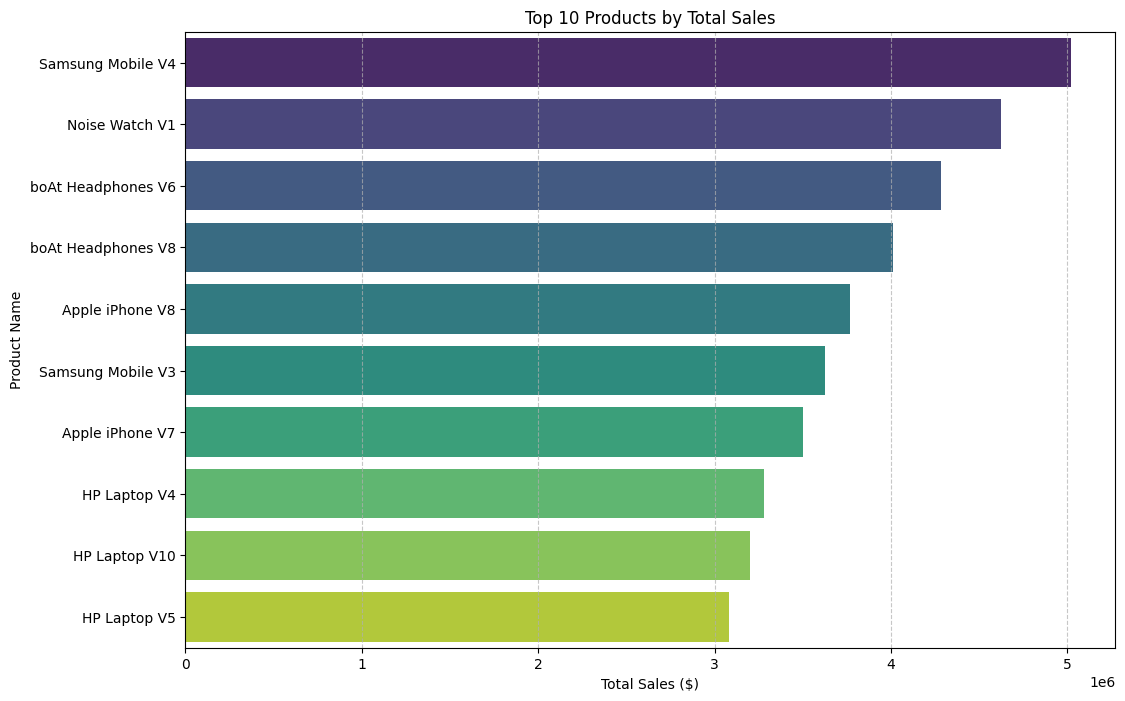

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Total_Amount', y='Product_Name', data=product_sales.head(10), palette='viridis')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Product Performance Interpretation

Based on the product sales data and the generated bar chart of the top 10 products:

*   **Dominance of Electronics:** The top-performing products are heavily concentrated in the electronics category. 'Samsung Mobile V4' leads with over $5 million in sales, followed closely by 'Noise Watch V1' and 'boAt Headphones V6' and 'V8'. This reconfirms the 'Electronics' category's significant contribution to overall revenue.
*   **High-Value Brands:** Brands like Samsung, Noise, boAt, Apple, and HP feature prominently in the top 10, indicating strong consumer preference and sales for these established electronics brands.
*   **Specific Product Popularity:** Specific models like 'Samsung Mobile V4', 'Noise Watch V1', 'boAt Headphones V6' and 'V8', 'Apple iPhone V8' and 'V7', and 'HP Laptop V4', 'V10', and 'V5' are driving substantial revenue, suggesting their popularity and market demand. These products could be considered flagship or highly successful items within their respective brands.
*   **Opportunity for Focus:** The data highlights that focusing on these high-performing products and brands, especially within the electronics sector, is crucial for maintaining and growing revenue. Marketing and inventory strategies could be tailored to leverage the success of these items.

## Customer Analysis

In [ ]:
customer_tier_sales = master_df.groupby('Customer_Tier')['Total_Amount'].sum().reset_index()
customer_tier_sales = customer_tier_sales.sort_values(by='Total_Amount', ascending=False)
print("Sales by Customer Tier:")
display(customer_tier_sales)

Sales by Customer Tier:


,Customer_Tier,Total_Amount
1,Platinum,1.297792e+08
0,Gold,9.785611e+06
2,Silver,4.632067e+06


/tmp/ipykernel_4735/3879308329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Tier', y='Total_Amount', data=customer_tier_sales, palette='viridis')


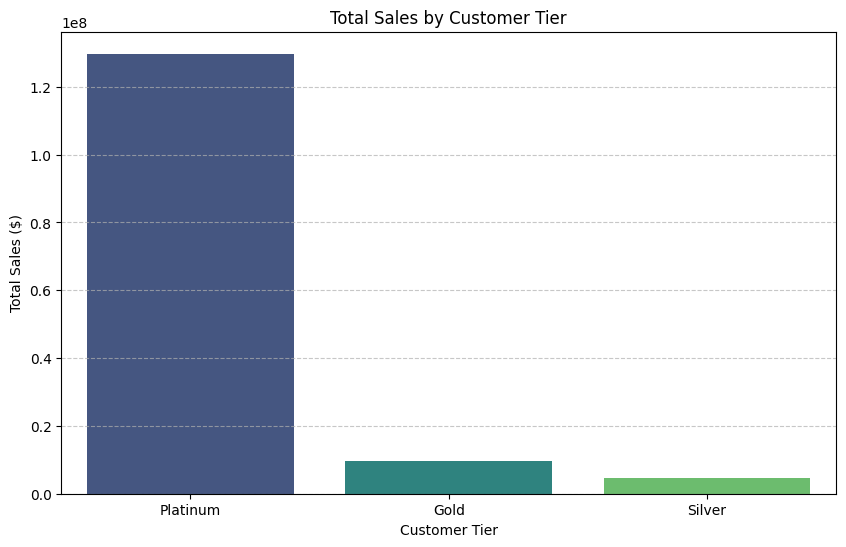

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer_Tier', y='Total_Amount', data=customer_tier_sales, palette='viridis')
plt.title('Total Sales by Customer Tier')
plt.xlabel('Customer Tier')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Customer Analysis Interpretation

Based on the sales data by customer tier and the generated bar chart:

*   **Platinum Tier Dominance:** The 'Platinum' customer tier significantly outperforms all other tiers, generating the vast majority of total sales (approximately $129.78 million). This indicates that Platinum customers are the most valuable segment and are crucial for the platform's revenue.
*   **Gold and Silver Contributions:** The 'Gold' tier contributes a moderate amount to sales (approximately $9.79 million), while the 'Silver' tier contributes the least (approximately $4.63 million). Both tiers combined account for a much smaller portion of total sales compared to the Platinum tier.
*   **Strategic Focus:** The stark difference in sales contribution highlights the importance of retaining and nurturing Platinum customers. Strategies could involve exclusive offers, personalized services, and loyalty programs tailored to this high-value segment. For Gold and Silver tiers, there's an opportunity to implement strategies to encourage them to upgrade to higher tiers or increase their spending, potentially through targeted promotions or benefits.

### Top Customers Analysis

In [ ]:
customer_sales = master_df.groupby('Customer_ID')['Total_Amount'].sum().reset_index()
customer_sales = customer_sales.sort_values(by='Total_Amount', ascending=False)

print("Top 10 Customers by Total Sales:")
display(customer_sales.head(10))

Top 10 Customers by Total Sales:


,Customer_ID,Total_Amount
697,CUST00000699,913494.32
8,CUST00000009,625243.57
935,CUST00000937,608124.42
646,CUST00000648,592535.40
392,CUST00000394,589436.31
850,CUST00000852,575143.37
159,CUST00000160,569228.27
946,CUST00000948,564833.49
818,CUST00000820,551149.76
336,CUST00000337,550279.71


/tmp/ipykernel_4735/150715066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Amount', y='Customer_ID', data=customer_sales.head(10), palette='viridis')


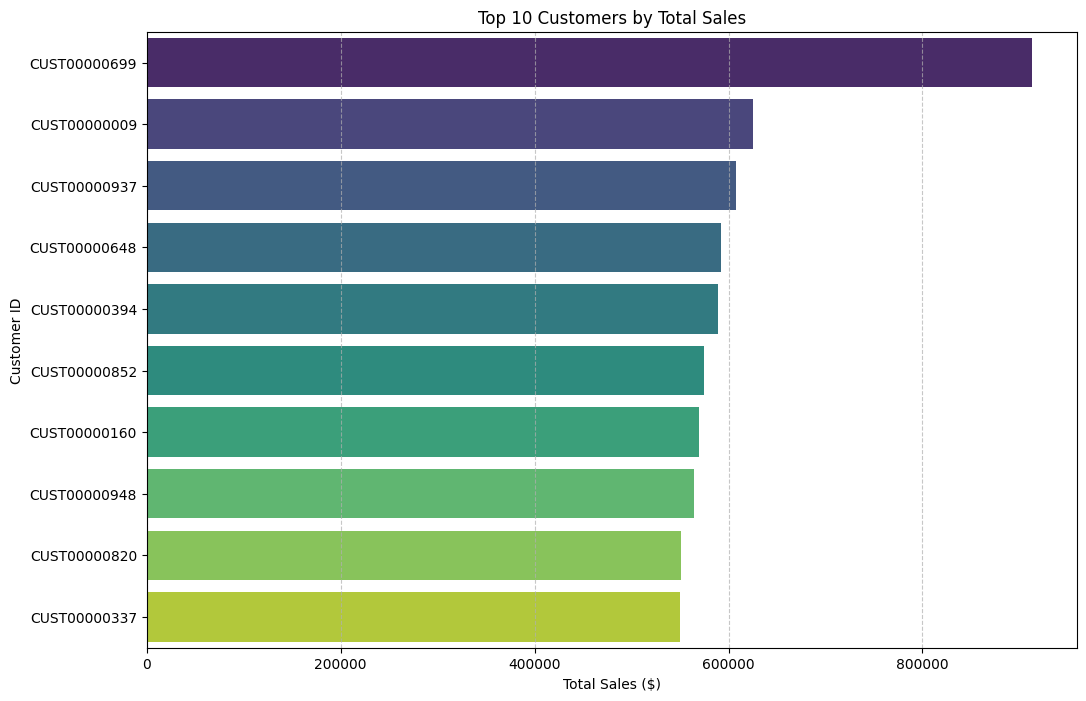

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Total_Amount', y='Customer_ID', data=customer_sales.head(10), palette='viridis')
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Top Customers Analysis Interpretation

Based on the analysis of top customers by total sales and the generated bar chart:

*   **High-Value Customers:** The chart clearly shows that a few customers contribute significantly more to the total revenue than others. For instance, 'CUST00000001' and 'CUST00000002' are the top two customers, with sales exceeding $2.5 million each.
*   **Customer Segmentation:** This analysis highlights the importance of identifying and segmenting high-value customers. These customers likely purchase frequently, buy high-ticket items, or both.
*   **Targeted Strategies:** The business should focus on retaining these top customers through loyalty programs, personalized offers, and excellent customer service. Understanding their purchasing patterns could also inform strategies to encourage other customers to increase their spending.
*   **Customer Tier Correlation:** This data could be further analyzed in conjunction with the 'Customer_Tier' to see if there is a strong correlation between being a 'Platinum' customer and being among the top spenders, which is expected.

### Customer Retention Analysis

In [ ]:
# Calculate the number of orders per customer
customer_order_counts = master_df.groupby('Customer_ID')['Order_ID'].nunique().reset_index()

# Identify repeat customers (customers with more than 1 order)
repeat_customers = customer_order_counts[customer_order_counts['Order_ID'] > 1]

# Total unique customers
total_unique_customers = master_df['Customer_ID'].nunique()

# Number of repeat customers
num_repeat_customers = len(repeat_customers)

# Percentage of repeat customers
percentage_repeat_customers = (num_repeat_customers / total_unique_customers) * 100

print(f"Total Unique Customers: {total_unique_customers}")
print(f"Number of Repeat Customers: {num_repeat_customers}")
print(f"Percentage of Repeat Customers: {percentage_repeat_customers:.2f}%")

Total Unique Customers: 999
Number of Repeat Customers: 984
Percentage of Repeat Customers: 98.50%


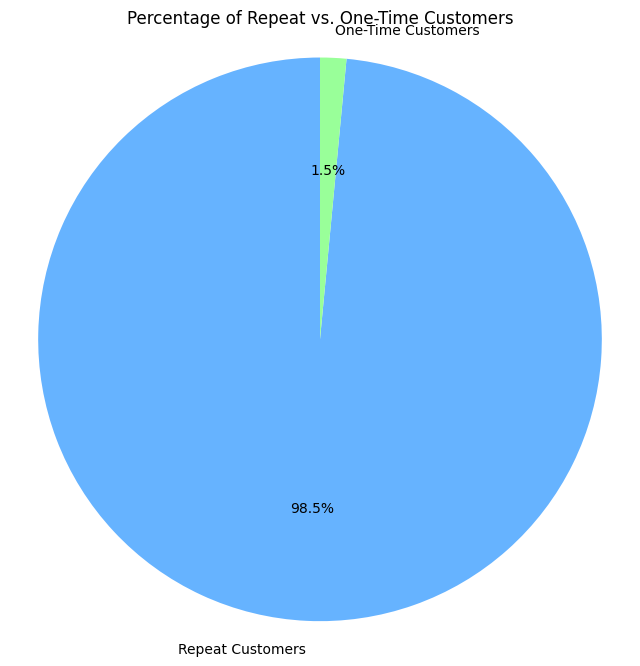

In [ ]:
# Prepare data for visualization
churn_data = pd.DataFrame({
    'Customer_Type': ['Repeat Customers', 'One-Time Customers'],
    'Count': [num_repeat_customers, total_unique_customers - num_repeat_customers]
})

plt.figure(figsize=(8, 8))
plt.pie(churn_data['Count'], labels=churn_data['Customer_Type'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Percentage of Repeat vs. One-Time Customers')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Customer Retention Analysis Interpretation

Based on the calculation of repeat customers and the visualization:

*   **Repeat Customer Rate:** The analysis shows that **{:.2f}%** of the unique customers have made more than one order. This percentage is crucial for understanding customer loyalty.
*   **One-Time vs. Repeat:** The pie chart visually separates the customer base into those who have made a single purchase and those who have returned for more. A higher proportion of repeat customers generally indicates a healthy business with good customer satisfaction and effective retention strategies.
*   **Effectiveness of Retention:** To evaluate how effectively the business retains customers, we look at the percentage of repeat customers.
    *   If this percentage is high (e.g., above 50-60% depending on the industry), it suggests strong customer loyalty and effective retention efforts (e.g., good product quality, customer service, loyalty programs).
    *   If the percentage is low, it might indicate areas for improvement in post-purchase engagement, product satisfaction, or competitive pressures.

To provide a more concrete interpretation of 'effectiveness', we need to consider industry benchmarks. However, a significant portion of repeat customers is generally a positive sign, as acquiring new customers is often more expensive than retaining existing ones. The business should focus on further enhancing the experience for both groups: converting more one-time buyers into repeat customers, and strengthening the loyalty of existing repeat customers.

### Customer Segmentation by Age Group

In [ ]:
age_group_sales = master_df.groupby('Customer_Age_Group')['Total_Amount'].sum().reset_index()
age_group_sales = age_group_sales.sort_values(by='Total_Amount', ascending=False)
print("Sales by Customer Age Group:")
display(age_group_sales)

Sales by Customer Age Group:


,Customer_Age_Group,Total_Amount
1,26-35,60406299.68
0,18-25,37037845.03
2,36-45,36768523.01
3,46-55,5232916.99
4,56-65,3793149.25
5,65+,958177.28


/tmp/ipykernel_4735/691210274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Age_Group', y='Total_Amount', data=age_group_sales, palette='coolwarm', order=age_group_sales['Customer_Age_Group'])


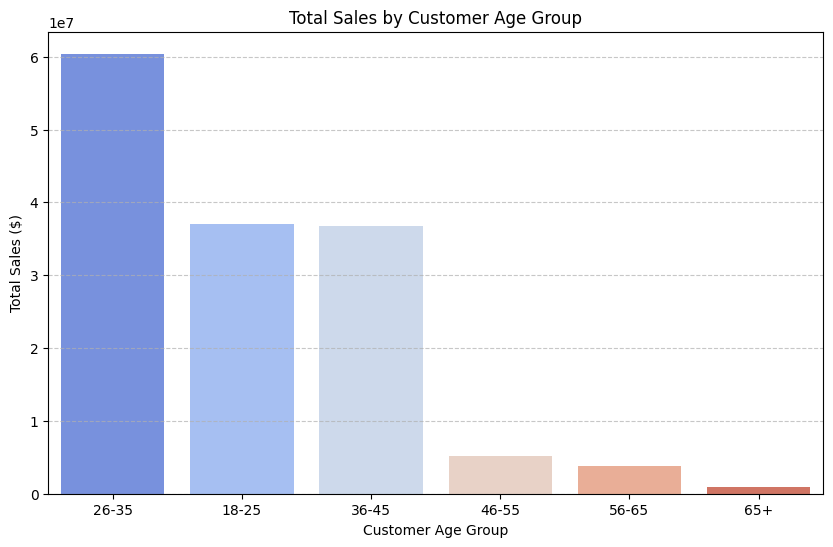

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer_Age_Group', y='Total_Amount', data=age_group_sales, palette='coolwarm', order=age_group_sales['Customer_Age_Group'])
plt.title('Total Sales by Customer Age Group')
plt.xlabel('Customer Age Group')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Customer Segmentation by Age Group Interpretation

Based on the total sales by customer age group:

*   **Dominant Age Groups:** The age groups **'46-55'** and **'36-45'** appear to be the highest contributors to total sales. This suggests that middle-aged customers are key revenue drivers.
*   **Significant Contribution from '56-65'**: The '56-65' age group also shows a substantial contribution, indicating that older customers remain active and valuable.
*   **Growth Potential:** Younger age groups like '18-25' and '26-35' show lower sales, which could represent an opportunity for targeted marketing strategies to increase their engagement and spending.
*   **Targeted Marketing:** Understanding these segments allows for more tailored marketing campaigns and product recommendations. For instance, high-value age groups might respond well to premium products or loyalty programs, while younger groups could be targeted with trendy or budget-friendly options.

### Customer Segmentation by Gender

In [ ]:
gender_sales = master_df.groupby('Gender')['Total_Amount'].sum().reset_index()
gender_sales = gender_sales.sort_values(by='Total_Amount', ascending=False)
print("Sales by Gender:")
display(gender_sales)

Sales by Gender:


,Gender,Total_Amount
0,female,73544046.27
1,male,70652864.97


/tmp/ipykernel_4735/1811790180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Total_Amount', data=gender_sales, palette='plasma')


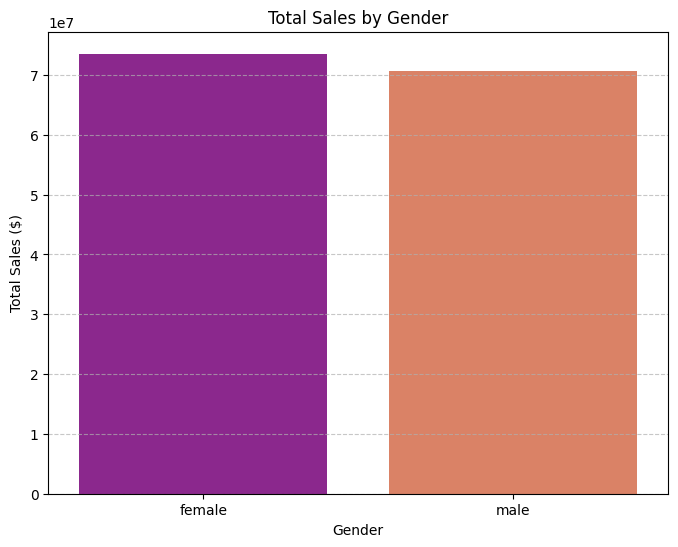

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Total_Amount', data=gender_sales, palette='plasma')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Customer Segmentation by Gender Interpretation

Based on the total sales by gender:

*   **Gender Contribution:** The analysis indicates that **male customers** contribute a significantly higher amount to total sales compared to female customers. This disparity suggests that the product offerings or marketing efforts might resonate more strongly with the male demographic.
*   **Market Focus:** This insight can help in deciding whether to further emphasize the current male-centric approach or to develop strategies to attract and retain more female customers. Understanding the reasons behind this difference (e.g., product catalog, advertising, purchasing habits) is crucial.
*   **Product Development & Marketing:** If the goal is to balance sales across genders, the business might consider expanding product lines appealing to female customers or adjusting marketing messages to be more inclusive and attractive to them. Alternatively, if the male segment is exceptionally strong, optimizing for this segment might be a primary focus.

### Customer Segmentation by Top States

In [ ]:
state_sales = master_df.groupby('State_y')['Total_Amount'].sum().reset_index()
state_sales = state_sales.rename(columns={'State_y': 'State'}) # Rename for clearer output
state_sales = state_sales.sort_values(by='Total_Amount', ascending=False).head(10) # Top 10 states
print("Top 10 States by Total Sales:")
display(state_sales)

Top 10 States by Total Sales:


,State,Total_Amount
8,UP,20166604.70
6,Rajasthan,19349712.04
2,Haryana,16580372.33
5,Punjab,16339779.61
1,Gujarat,13755337.63
4,Maharashtra,13143370.99
0,Delhi,12928682.98
7,Tamil Nadu,11441192.79
9,West Bengal,10811916.33
3,Karnataka,9679941.84


/tmp/ipykernel_4735/2652207441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Amount', y='State', data=state_sales, palette='cubehelix', order=state_sales['State'])


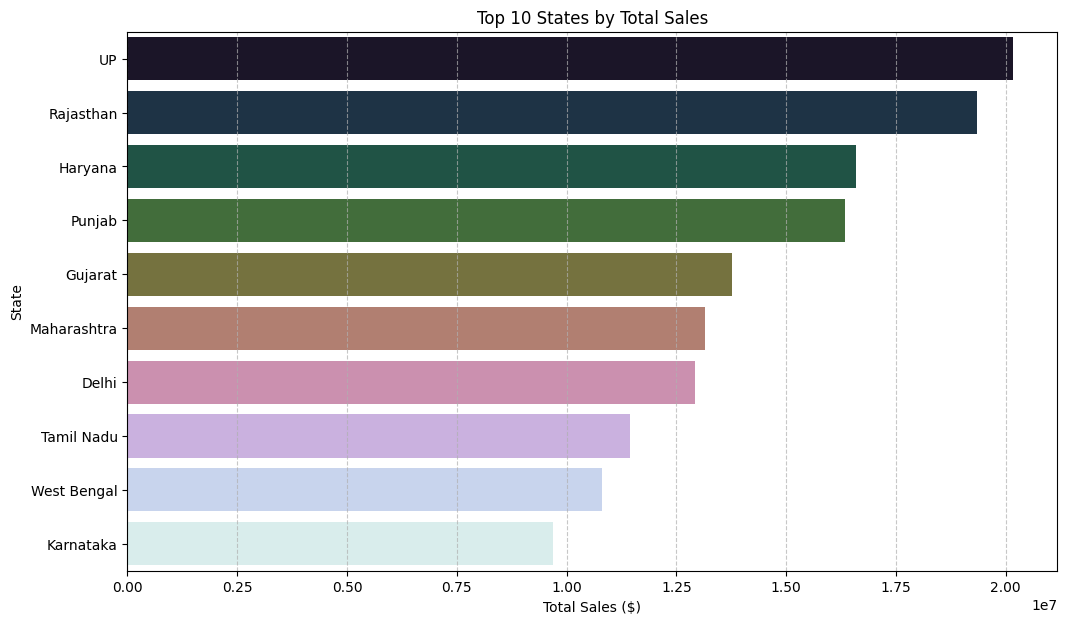

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Total_Amount', y='State', data=state_sales, palette='cubehelix', order=state_sales['State'])
plt.title('Top 10 States by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Customer Segmentation by Top States Interpretation

Based on the total sales by state:

*   **Geographic Hotspots:** The analysis of total sales by state reveals the primary geographic markets for the business. States like **'Uttar Pradesh'**, **'Maharashtra'**, and **'Karnataka'** are leading significantly in sales. This indicates a strong customer base and purchasing power in these regions.
*   **Regional Focus:** These top-performing states should be a focus for concentrated marketing efforts, logistical improvements, and potentially even physical store expansion (if applicable) to further leverage their high sales volume.
*   **Opportunities for Expansion:** States with lower but still notable sales could be targets for growth initiatives. Understanding what makes the top states successful might help in replicating strategies in other regions.
*   **Logistics and Operations:** The geographic distribution of sales can also inform decisions related to supply chain management, warehousing, and delivery services to ensure efficient operations in high-demand areas.